In [70]:
#load required packages
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#set data directory
data_dir = ''

In [73]:
# load the first sheet of the Excel file into a data frame
metadata = pd.read_excel('Q3_Normalize_progression.xlsx', sheet_name='SegmentProperties')
# load normalized counts
norm = pd.read_excel('Q3_Normalize_progression.xlsx', sheet_name='TargetCountMatrix')

In [74]:
#preview normalized df
norm

,TargetName,BT2015013_001_core,BT2015013_002_core,BT2015013_003_core,BT2015013_004_core,BT2015013_005_core,BT2015013_006_core,18-17149_007_core,18-17149_008_edge,18-17149_009_edge,...,18-17149_013_edge,18-17149_014_core,18-17149_015_core,18-17149_016_core,15-1842_017_edge,15-1842_018_edge,15-1842_019_edge,15-1842_020_edge,18-17149_021_edge,BT2015013_022_core
0,TLK1,14.746853,13.864562,11.703851,10.240870,13.654493,13.927583,10.602312,9.486279,12.874236,...,14.200673,21.427051,13.798225,10.348669,18.433566,10.923595,24.578088,9.831235,10.602312,14.746853
1,APOL2,9.831235,8.822903,7.022311,12.289044,12.289044,12.289044,31.806937,22.422115,25.748473,...,21.847189,13.864562,19.834948,20.697337,18.433566,5.461797,6.554157,13.108313,14.457699,4.915618
2,CIDEA,22.939549,16.385392,4.681541,18.433566,9.558145,21.301009,12.530006,17.247781,11.703851,...,22.939549,13.864562,18.110170,15.523003,18.433566,10.923595,16.385392,13.108313,12.530006,15.566122
3,RAB33B,8.192696,5.041659,11.703851,8.192696,12.289044,9.831235,7.710773,8.623890,9.363081,...,7.646516,10.083318,12.935836,11.211058,12.289044,16.385392,6.554157,6.554157,10.602312,5.734887
4,BORCS7,11.469774,11.343733,4.681541,6.144522,10.923595,8.192696,7.710773,9.486279,15.215007,...,7.646516,7.562489,6.036723,6.899112,20.481740,16.385392,8.192696,13.108313,10.602312,6.554157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16937,MT1E,8.738876,13.864562,16.385392,10.240870,16.385392,9.011966,26.023858,12.935836,35.111554,...,16.385392,11.343733,12.935836,18.972559,22.529914,10.923595,31.132244,13.108313,5.783079,8.192696
16938,LEMD1,8.192696,7.562489,2.340770,10.240870,4.096348,7.373426,12.530006,8.623890,14.044622,...,8.738876,2.520830,4.311945,5.174334,10.240870,16.385392,6.554157,3.277078,8.674619,7.373426
16939,BICDL1,8.192696,5.041659,14.044622,6.144522,8.192696,3.277078,6.746926,6.899112,9.363081,...,10.923595,11.343733,6.036723,7.761501,6.144522,5.461797,11.469774,13.108313,7.710773,6.554157
16940,PPIL3,9.831235,6.302074,4.681541,8.192696,6.827247,9.011966,8.674619,12.073447,11.703851,...,7.646516,3.781244,7.761501,14.660614,4.096348,10.923595,22.939549,9.831235,7.710773,8.192696


In [75]:
#set index to TargetName and transpose
norm.set_index('TargetName', inplace=True)
norm = norm.T

In [76]:
#convert to anndata
ad_norm = sc.AnnData(norm)

In [77]:
#preview obs
ad_norm.obs

""
BT2015013_001_core
BT2015013_002_core
BT2015013_003_core
BT2015013_004_core
BT2015013_005_core
BT2015013_006_core
18-17149_007_core
18-17149_008_edge
18-17149_009_edge
18-17149_010_core


In [78]:
#preview metadata
metadata.set_index('SegmentDisplayName', inplace=True)

In [79]:
ad_norm

AnnData object with n_obs × n_vars = 22 × 16942

In [80]:
#preview metadata
metadata

,SlideName,ScanLabel,ROILabel,SegmentLabel,Origin Instrument ID,QCFlags,AOISurfaceArea,AOINucleiCount,ROICoordinateX,ROICoordinateY,...,ScanOffsetX,ScanOffsetY,LOQ (Human NGS Whole Transcriptome Atlas RNA_1.0),NormalizationFactor,ExpressionFilteringThreshold (Human NGS Whole Transcriptome Atlas RNA_1.0),ROIComments,Grade,core_edge,Ki67%,comparison
SegmentDisplayName,,,,,,,,,,,,,,,,,,,,,
BT2015013_001_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,001_HPT,HPT,1912G0058,NaN,70585.055185,399,19696.984375,11210.625000,...,4255,2111,31.856269,0.546180,31.856269,BT2015013_001_core,Grade 4,core,0.505902,IV
BT2015013_002_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,002_HPT,HPT,1912G0058,NaN,70585.055185,346,15610.031250,10499.303711,...,4255,2111,14.951259,1.260415,14.951259,BT2015013_002_core,Grade 4,core,2.539683,IV
BT2015013_003_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,003_T,T,1912G0058,Low Negative Probe Count for Probe Kit Human N...,31431.869711,279,24054.976562,11330.706055,...,4255,2111,7.412753,2.340770,7.412753,BT2015013_003_core,Grade 4,core,0.000000,IV
BT2015013_004_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,004_T,T,1912G0058,Low Negative Probe Count for Probe Kit Human N...,31431.869711,191,23429.330078,10156.845703,...,4255,2111,7.923601,2.048174,7.923601,BT2015013_004_core,Grade 4,core,3.012048,IV
BT2015013_005_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,005_HPT,HPT,1912G0058,NaN,70585.055185,492,8032.611816,8304.255859,...,4255,2111,12.368833,1.365449,12.368833,BT2015013_005_core,Grade 4,core,4.899777,IV
BT2015013_006_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,006_T,T,1912G0058,NaN,70585.055185,356,18129.312500,7242.801758,...,4255,2111,20.724551,0.819270,20.724551,BT2015013_006_core,Grade 4,core,5.432937,IV
18-17149_007_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,007_HPT,HPT,1912G0058,NaN,125799.162357,704,18316.666016,35456.886719,...,4255,2111,25.081027,0.963847,25.081027,18-17149_007_core,Grade 3,core,3.426124,other
18-17149_008_edge,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,008_HPT,HPT,1912G0058,NaN,125799.162357,664,14559.695312,33928.160156,...,4255,2111,23.171498,0.862389,23.171498,18-17149_008_edge,Grade 3,edge,11.307420,other
18-17149_009_edge,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,009_HPT,HPT,1912G0058,NaN,125799.162357,490,15661.851562,33457.816406,...,4255,2111,17.667103,1.170385,17.667103,18-17149_009_edge,Grade 3,edge,5.167173,other


In [81]:
#reindex metadata to match ad_norm.obs
metadata = metadata.reindex(ad_norm.obs.index)
metadata

,SlideName,ScanLabel,ROILabel,SegmentLabel,Origin Instrument ID,QCFlags,AOISurfaceArea,AOINucleiCount,ROICoordinateX,ROICoordinateY,...,ScanOffsetX,ScanOffsetY,LOQ (Human NGS Whole Transcriptome Atlas RNA_1.0),NormalizationFactor,ExpressionFilteringThreshold (Human NGS Whole Transcriptome Atlas RNA_1.0),ROIComments,Grade,core_edge,Ki67%,comparison
BT2015013_001_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,001_HPT,HPT,1912G0058,NaN,70585.055185,399,19696.984375,11210.625000,...,4255,2111,31.856269,0.546180,31.856269,BT2015013_001_core,Grade 4,core,0.505902,IV
BT2015013_002_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,002_HPT,HPT,1912G0058,NaN,70585.055185,346,15610.031250,10499.303711,...,4255,2111,14.951259,1.260415,14.951259,BT2015013_002_core,Grade 4,core,2.539683,IV
BT2015013_003_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,003_T,T,1912G0058,Low Negative Probe Count for Probe Kit Human N...,31431.869711,279,24054.976562,11330.706055,...,4255,2111,7.412753,2.340770,7.412753,BT2015013_003_core,Grade 4,core,0.000000,IV
BT2015013_004_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,004_T,T,1912G0058,Low Negative Probe Count for Probe Kit Human N...,31431.869711,191,23429.330078,10156.845703,...,4255,2111,7.923601,2.048174,7.923601,BT2015013_004_core,Grade 4,core,3.012048,IV
BT2015013_005_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,005_HPT,HPT,1912G0058,NaN,70585.055185,492,8032.611816,8304.255859,...,4255,2111,12.368833,1.365449,12.368833,BT2015013_005_core,Grade 4,core,4.899777,IV
BT2015013_006_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,006_T,T,1912G0058,NaN,70585.055185,356,18129.312500,7242.801758,...,4255,2111,20.724551,0.819270,20.724551,BT2015013_006_core,Grade 4,core,5.432937,IV
18-17149_007_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,007_HPT,HPT,1912G0058,NaN,125799.162357,704,18316.666016,35456.886719,...,4255,2111,25.081027,0.963847,25.081027,18-17149_007_core,Grade 3,core,3.426124,other
18-17149_008_edge,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,008_HPT,HPT,1912G0058,NaN,125799.162357,664,14559.695312,33928.160156,...,4255,2111,23.171498,0.862389,23.171498,18-17149_008_edge,Grade 3,edge,11.307420,other
18-17149_009_edge,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,009_HPT,HPT,1912G0058,NaN,125799.162357,490,15661.851562,33457.816406,...,4255,2111,17.667103,1.170385,17.667103,18-17149_009_edge,Grade 3,edge,5.167173,other
18-17149_010_core,15-1842_18-17149_BT201503,15-1842_18-17149_BT 201503_C,010_HPT,HPT,1912G0058,NaN,125799.162357,673,19298.414062,36418.308594,...,4255,2111,19.600852,1.170385,19.600852,18-17149_010_core,Grade 3,core,5.333333,other


In [82]:
#add metadata to ad_norm
ad_norm.obs = metadata

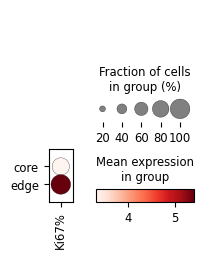

In [83]:
#plot dotplot of Ki67% in histology groups
sc.pl.dotplot(ad_norm, groupby='core_edge', var_names=['Ki67%'])

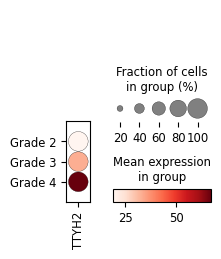

In [84]:
#plot dotplot of TTYH2 in progression stages
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['TTYH2'])


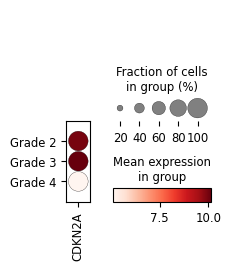

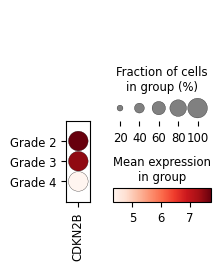

In [85]:
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['CDKN2A'])
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['CDKN2B'])

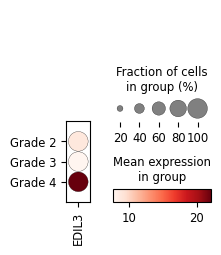

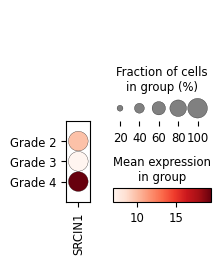

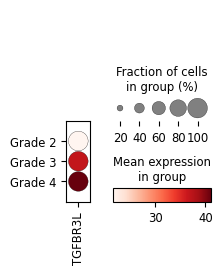

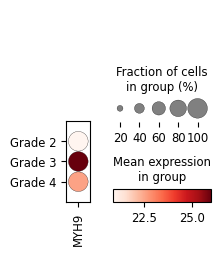

In [17]:
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['EDIL3'])
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['SRCIN1'])
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['TGFBR3L'])
sc.pl.dotplot(ad_norm, groupby='Grade', var_names=['MYH9'])

In [86]:
# normalization already done so skipping that step and going to PCA/UMAP
sc.pp.pca(ad_norm, n_comps=21)
sc.pp.neighbors(ad_norm, n_neighbors=9)
sc.tl.umap(ad_norm)

In [87]:
#calculate leiden clusters
sc.tl.leiden(ad_norm, resolution=3)

In [88]:
#regression plots
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
import seaborn as sns
import numpy as np

In [89]:
# Extract data from ad_norm
df = pd.DataFrame({
    'Ki67%': ad_norm.obs['Ki67%'],
    'TTYH2_expr': ad_norm[:, 'TTYH2'].X.flatten(),
    'MYH2_expr': ad_norm[:, 'MYH2'].X.flatten(),
    'DNAJB2_expr': ad_norm[:, 'DNAJB2'].X.flatten(),
    'TUBB4A_expr': ad_norm[:, 'TUBB4A'].X.flatten(),
    'ZEB1_expr': ad_norm[:, 'ZEB1'].X.flatten(),
    'SOX4_expr': ad_norm[:, 'SOX4'].X.flatten(),
    'MKI67_expr': ad_norm[:, 'MKI67'].X.flatten(),
    'Grade': ad_norm.obs['Grade']
})

In [22]:
df

,Ki67%,TTYH2_expr,MYH2_expr,DNAJB2_expr,TUBB4A_expr,ZEB1_expr,SOX4_expr,MKI67_expr,Grade
BT2015013_001_core,0.505902,67.180107,8.192696,51.340894,86.296397,127.806056,93.942913,8.738876,Grade 4
BT2015013_002_core,2.539683,73.104056,10.083318,50.416590,97.051936,128.562305,71.843641,6.302074,Grade 4
BT2015013_003_core,0.000000,81.926959,16.385392,72.563878,105.334662,114.697743,107.675432,11.703851,Grade 4
BT2015013_004_core,3.012048,67.589741,12.289044,36.867132,63.493393,159.757570,90.119655,6.144522,Grade 4
BT2015013_005_core,4.899777,42.328929,6.827247,36.867132,158.392121,86.023307,84.657858,2.730899,Grade 4
BT2015013_006_core,5.432937,67.180107,13.108313,49.156176,79.469150,129.444596,90.119655,4.915618,Grade 4
18-17149_007_core,3.426124,26.987704,8.674619,33.734630,18.313085,84.818499,89.637732,7.710773,Grade 3
18-17149_008_edge,11.307420,29.321228,6.899112,37.945118,14.660614,73.303069,94.862795,10.348669,Grade 3
18-17149_009_edge,5.167173,22.237317,4.681541,29.259628,14.044622,57.348871,70.223108,5.851926,Grade 3
18-17149_010_core,5.333333,26.918858,8.192696,32.770784,18.726162,84.267729,43.304250,3.511155,Grade 3


In [90]:
# Prepare X and y for regression
X = df['TTYH2_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values

In [91]:
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_

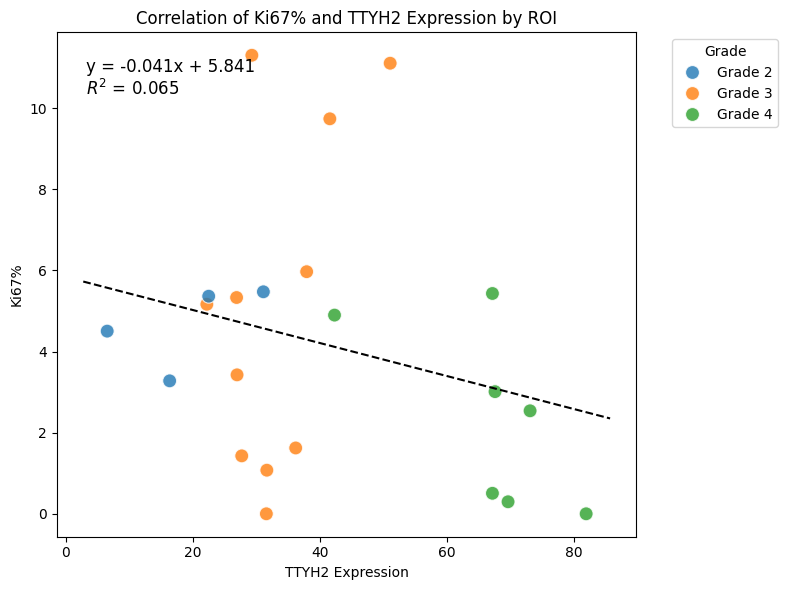

In [92]:
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='TTYH2_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('TTYH2 Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and TTYH2 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


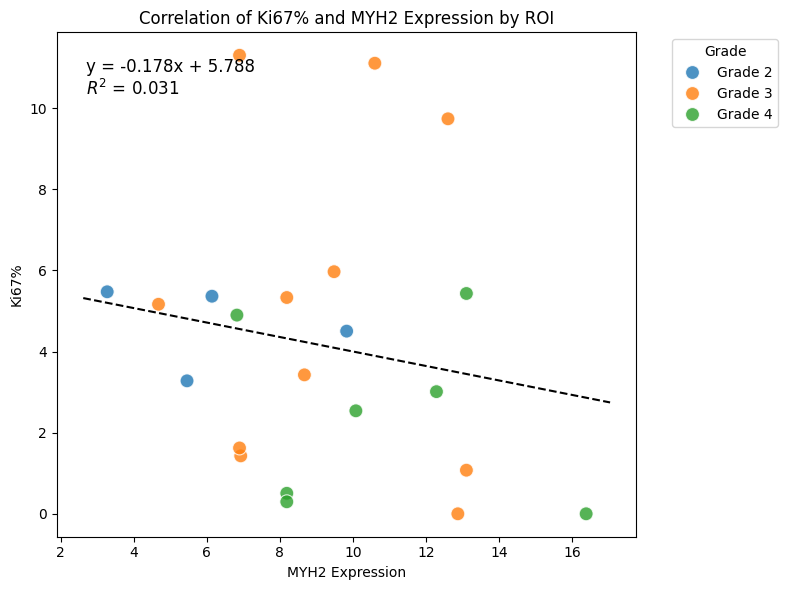

In [93]:
# Prepare X and y for regression
X = df['MYH2_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MYH2_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('MYH2 Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and MYH2 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

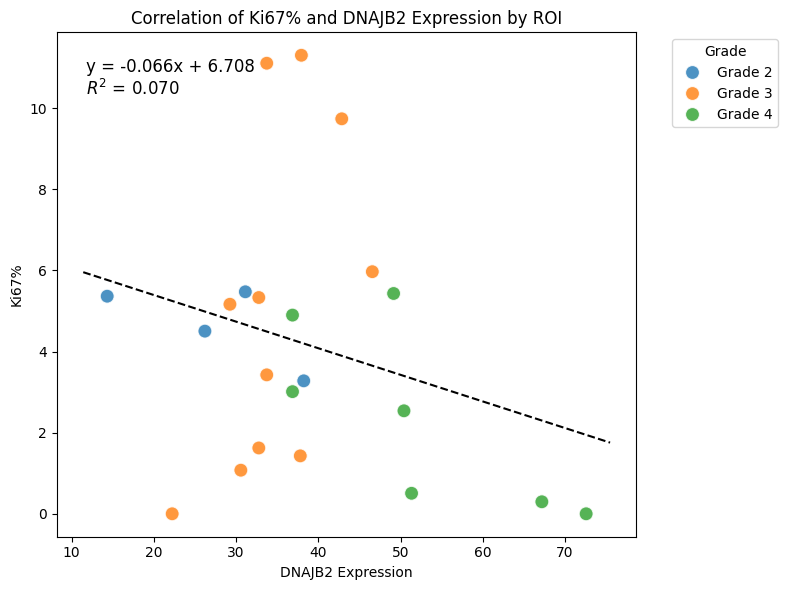

In [94]:
# Prepare X and y for regression
X = df['DNAJB2_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='DNAJB2_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('DNAJB2 Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and DNAJB2 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

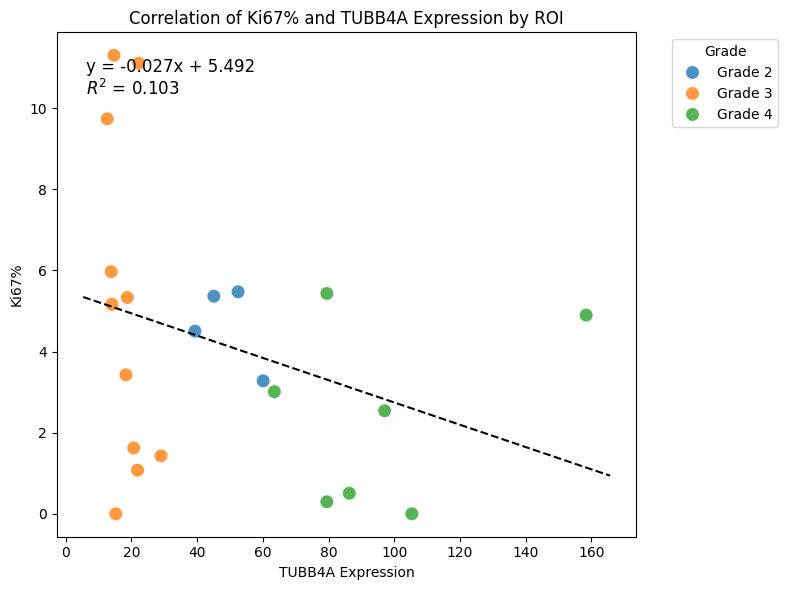

In [201]:
# Prepare X and y for regression
X = df['TUBB4A_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='TUBB4A_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('TUBB4A Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and TUBB4A Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

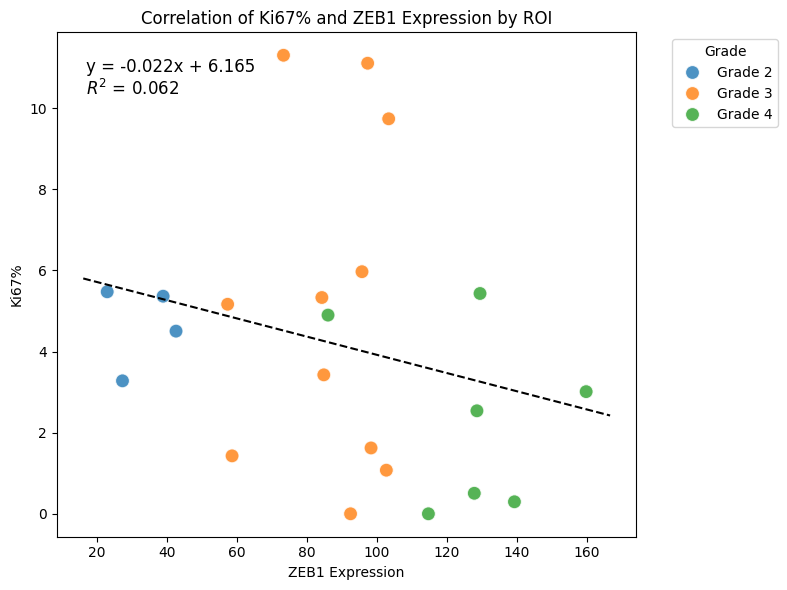

In [202]:
# Prepare X and y for regression
X = df['ZEB1_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ZEB1_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('ZEB1 Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and ZEB1 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

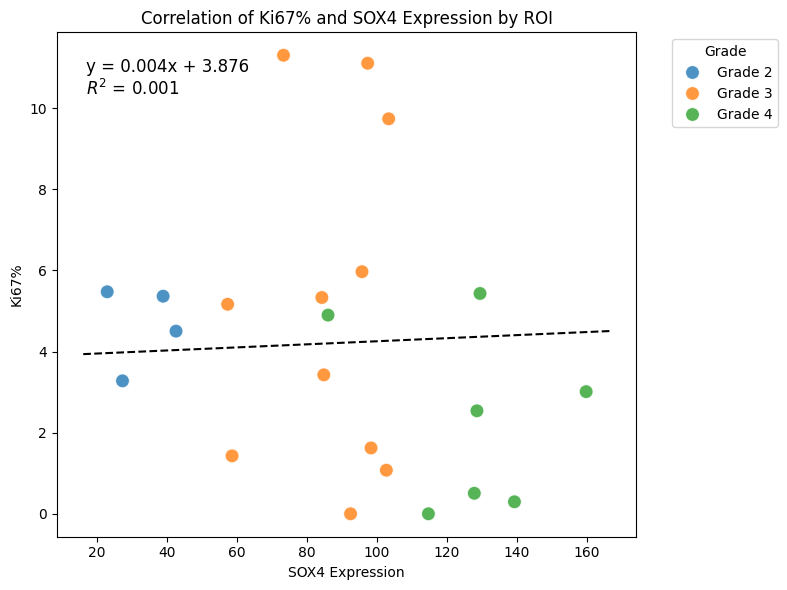

In [203]:
# Prepare X and y for regression
X = df['SOX4_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ZEB1_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('SOX4 Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and SOX4 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

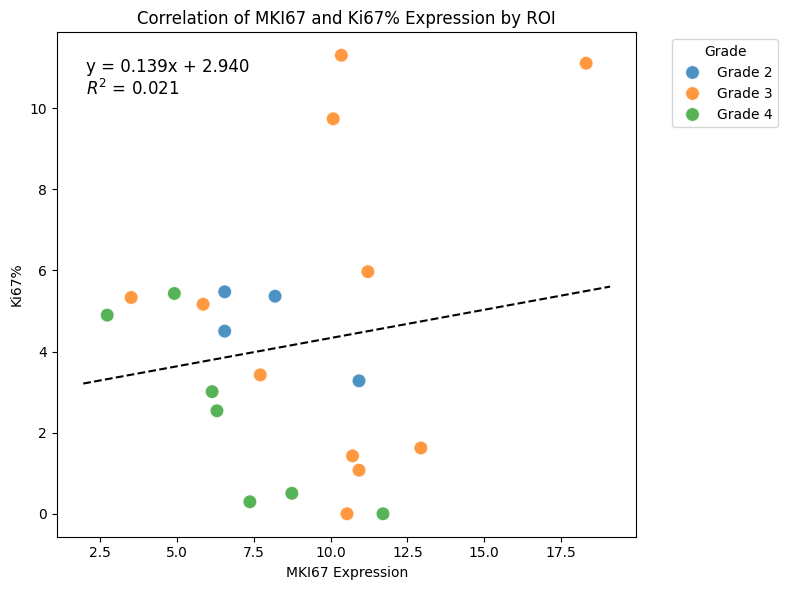

In [204]:
# Prepare X and y for regression
X = df['MKI67_expr'].values.reshape(-1, 1)
y = df['Ki67%'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MKI67_expr', y='Ki67%', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('MKI67 Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of MKI67 and Ki67% Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

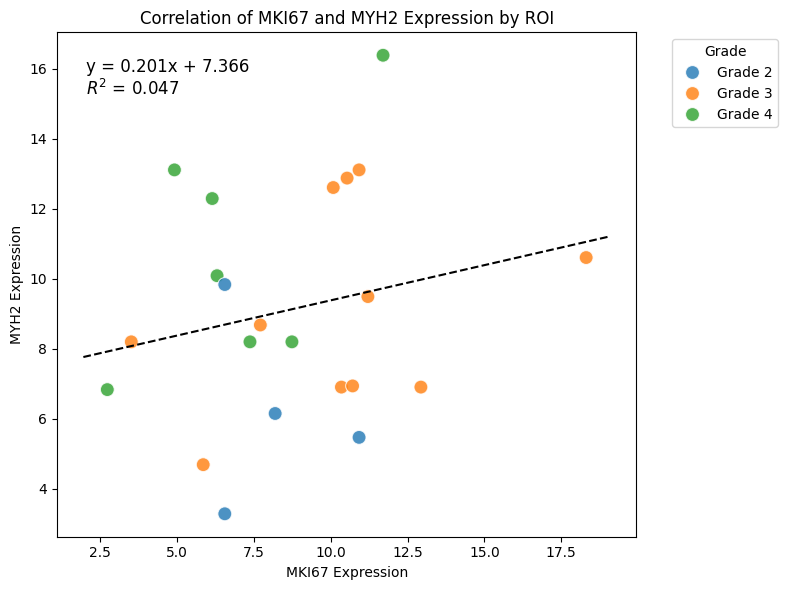

In [205]:
# Prepare X and y for regression
X = df['MKI67_expr'].values.reshape(-1, 1)
y = df['MYH2_expr'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MKI67_expr', y='MYH2_expr', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('MKI67 Expression')
plt.ylabel('MYH2 Expression')
plt.title('Correlation of MKI67 and MYH2 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

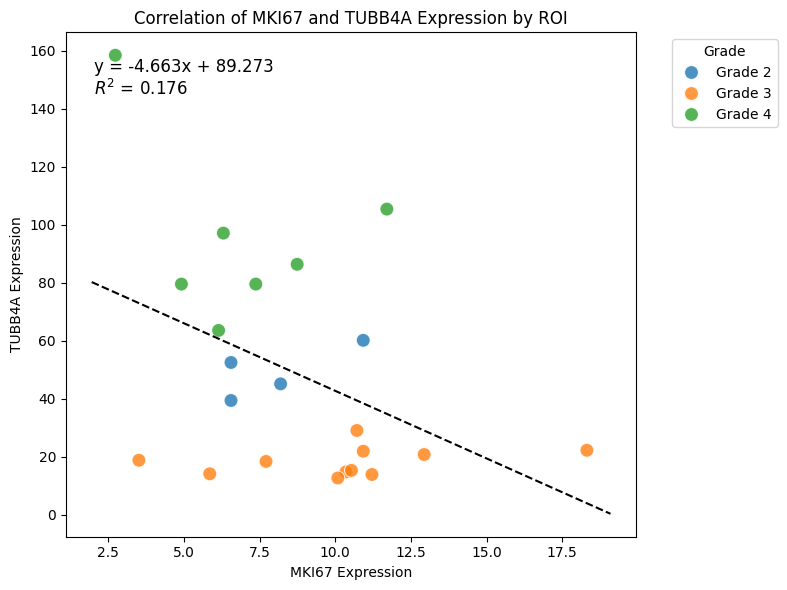

In [206]:
# Prepare X and y for regression
X = df['MKI67_expr'].values.reshape(-1, 1)
y = df['TUBB4A_expr'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MKI67_expr', y='TUBB4A_expr', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('MKI67 Expression')
plt.ylabel('TUBB4A Expression')
plt.title('Correlation of MKI67 and TUBB4A Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

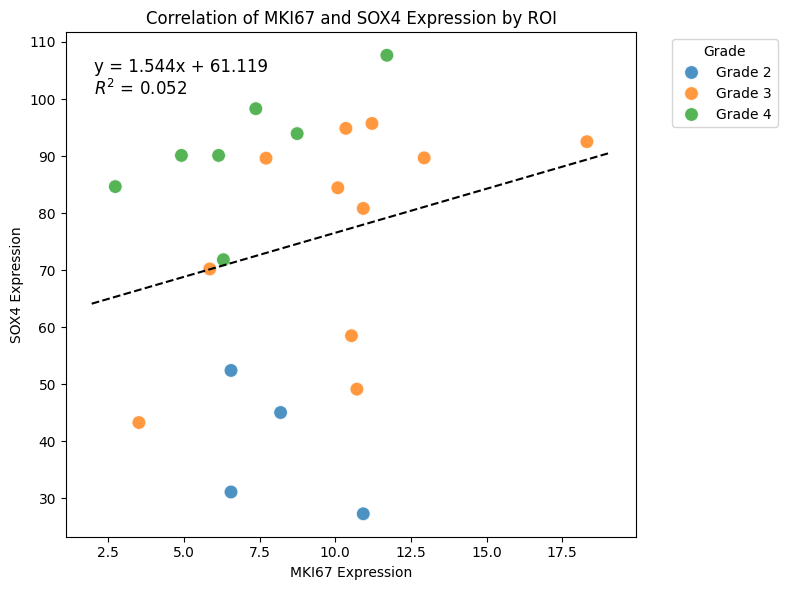

In [207]:
# Prepare X and y for regression
X = df['MKI67_expr'].values.reshape(-1, 1)
y = df['SOX4_expr'].values
# Fit linear regression
model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MKI67_expr', y='SOX4_expr', hue='Grade', s=100, alpha=0.8)

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black')

# Annotation: regression equation + R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('MKI67 Expression')
plt.ylabel('SOX4 Expression')
plt.title('Correlation of MKI67 and SOX4 Expression by ROI')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

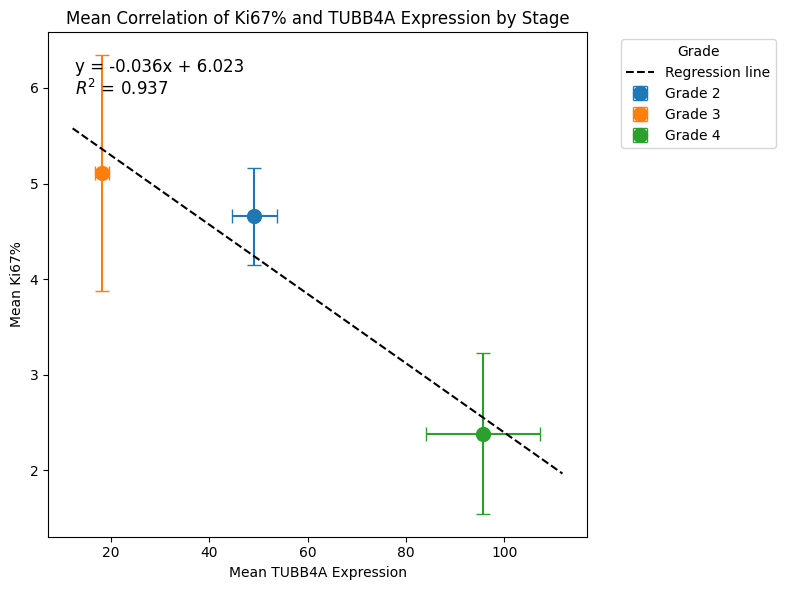

In [101]:
# Prepare DataFrame
df = pd.DataFrame({
    'Ki67%': ad_norm.obs['Ki67%'],
    'TUBB4A_expr': ad_norm[:, 'TUBB4A'].X.flatten(),
    'Grade': ad_norm.obs['Grade']
})

# Group by stage and calculate mean, std, count
grouped = df.groupby('Grade').agg({
    'Ki67%': ['mean', 'std', 'count'],
    'TUBB4A_expr': ['mean', 'std']
})

grouped.columns = ['_'.join(col) for col in grouped.columns]
grouped = grouped.reset_index()

# Calculate standard error
grouped['Ki67_se'] = grouped['Ki67%_std'] / np.sqrt(grouped['Ki67%_count'])
grouped['TUBB4A_se'] = grouped['TUBB4A_expr_std'] / np.sqrt(grouped['Ki67%_count'])

# Regression on means
X = grouped['TUBB4A_expr_mean'].values.reshape(-1, 1)
y = grouped['Ki67%_mean'].values

model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# Setup plot
plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", n_colors=len(grouped))

# Plot each stage point with error bars and color
for i, row in grouped.iterrows():
    plt.errorbar(
        row['TUBB4A_expr_mean'], row['Ki67%_mean'],
        xerr=row['TUBB4A_se'], yerr=row['Ki67_se'],
        fmt='o', capsize=5, markersize=10,
        label=row['Grade'], color=palette[i]
    )

# Regression line
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black', label='Regression line')

# Regression equation and R²
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('Mean TUBB4A Expression')
plt.ylabel('Mean Ki67%')
plt.title('Mean Correlation of Ki67% and TUBB4A Expression by Stage')
plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


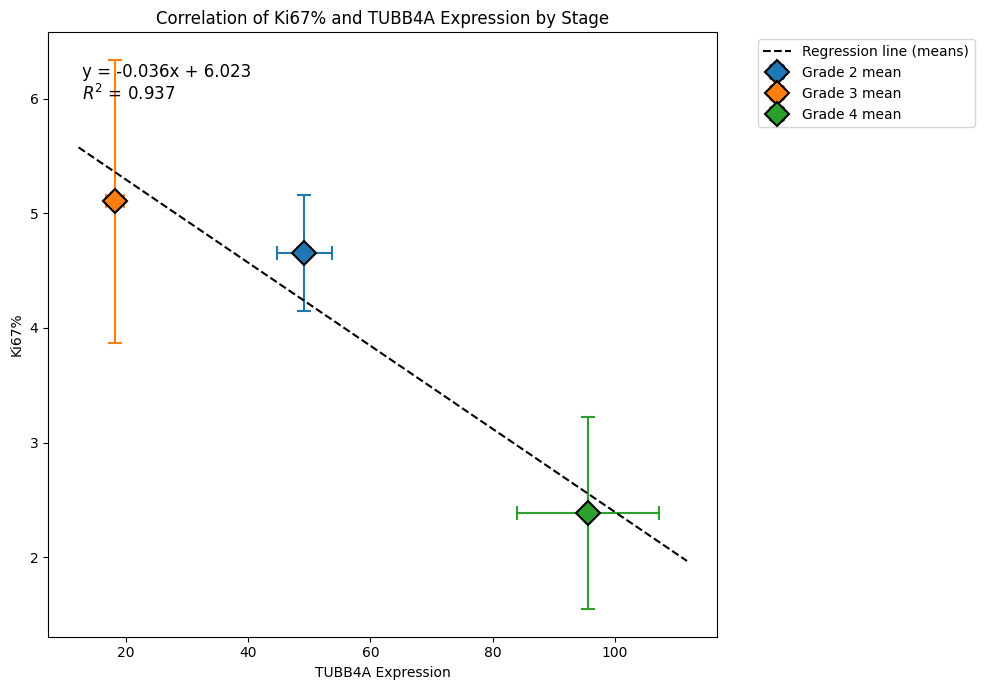

In [98]:
# Prepare DataFrame
df = pd.DataFrame({
    'Ki67%': ad_norm.obs['Ki67%'],
    'TUBB4A_expr': ad_norm[:, 'TUBB4A'].X.flatten(),
    'Grade': ad_norm.obs['Grade']
})

# Group by stage and calculate mean, std, count
grouped = df.groupby('Grade').agg({
    'Ki67%': ['mean', 'std', 'count'],
    'TUBB4A_expr': ['mean', 'std']
})

grouped.columns = ['_'.join(col) for col in grouped.columns]
grouped = grouped.reset_index()

# Calculate standard error
grouped['Ki67_se'] = grouped['Ki67%_std'] / np.sqrt(grouped['Ki67%_count'])
grouped['TUBB4A_se'] = grouped['TUBB4A_expr_std'] / np.sqrt(grouped['Ki67%_count'])

# Regression on means
X = grouped['TUBB4A_expr_mean'].values.reshape(-1, 1)
y = grouped['Ki67%_mean'].values

model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# Setup plot
plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", n_colors=len(grouped))

# Plot individual points colored by stage
#sns.scatterplot(data=df, x='MYH2_expr', y='Ki67%', hue='Grade', palette=palette, alpha=0.5, s=50, edgecolor=None)

# Plot grouped means with error bars and matching colors
for i, row in grouped.iterrows():
    plt.errorbar(
        row['TUBB4A_expr_mean'], row['Ki67%_mean'],
        xerr=row['TUBB4A_se'], yerr=row['Ki67_se'],
        fmt='o', capsize=5, markersize=12,
        label=f"{row['Grade']} mean", color=palette[i], marker='D', mec='black', mew=1.5
    )

# Regression line based on means
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='black', label='Regression line (means)')

# Regression equation and R^2 annotation
plt.text(
    0.05, 0.95,
    f'y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r_sq:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel('TUBB4A Expression')
plt.ylabel('Ki67%')
plt.title('Correlation of Ki67% and TUBB4A Expression by Stage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Differential Expression analysis using deseq2

In [102]:
### deseq2 DE
#https://pydeseq2.readthedocs.io/en/latest/auto_examples/plot_step_by_step.html#sphx-glr-auto-examples-plot-step-by-step-py 
import os
import pickle as pkl
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

In [103]:
SAVE = False

In [104]:
#load counts
counts_df = pd.read_excel('Q3_Normalize_progression.xlsx', sheet_name='TargetCountMatrix')
counts_df.set_index('TargetName', inplace=True)
counts_df = counts_df.astype(int)
counts_df = counts_df.T
print(counts_df)

TargetName          TLK1  APOL2  CIDEA  RAB33B  BORCS7  THOC1  MMRN2  VPS33B  \
BT2015013_001_core    14      9     22       8      11      9      1      10   
BT2015013_002_core    13      8     16       5      11     10      7       7   
BT2015013_003_core    11      7      4      11       4     14      2       9   
BT2015013_004_core    10     12     18       8       6     18     10      24   
BT2015013_005_core    13     12      9      12      10     12      6       8   
BT2015013_006_core    13     12     21       9       8     10      5      13   
18-17149_007_core     10     31     12       7       7     12     11       9   
18-17149_008_edge      9     22     17       8       9     12      5       3   
18-17149_009_edge     12     25     11       9      15      8      7       9   
18-17149_010_core     10     24     18       9       8     10      5       7   
18-17149_011_core      3     12     12       7      14     10      3      15   
18-17149_012_edge     10     12     17  

In [105]:
#load metadata
metadata_df = pd.read_excel('Q3_Normalize_progression.xlsx', sheet_name='SegmentProperties')
metadata_df.set_index('SegmentDisplayName', inplace=True)
# Make sure 'comparison' is a categorical column
metadata_df['comparison'] = metadata_df['comparison'].astype('category')
# Set the reference level to "other"
metadata_df['comparison'] = metadata_df['comparison'].cat.reorder_categories(['other', 'IV'], ordered=True)
print(metadata_df)

                                    SlideName                     ScanLabel  \
SegmentDisplayName                                                            
BT2015013_001_core  15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
BT2015013_002_core  15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
BT2015013_003_core  15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
BT2015013_004_core  15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
BT2015013_005_core  15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
BT2015013_006_core  15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
18-17149_007_core   15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
18-17149_008_edge   15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
18-17149_009_edge   15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
18-17149_010_core   15-1842_18-17149_BT201503  15-1842_18-17149_BT 201503_C   
18-17149_011_core   15-1842_18-17149_BT201503  15-18

In [106]:
#Single factor analysis stage (united IV vs other)
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design_factors="comparison",
    refit_cooks=True,
    inference=inference,
)

In [107]:
inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design_factors="comparison",
    refit_cooks=True,
    inference=inference,
    ref_level=["comparison", "other"]  # Set "other" as the reference level
)

In [108]:
dds.deseq2()
print(dds)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 1.97 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 1.47 seconds.

Fitting LFCs...


AnnData object with n_obs × n_vars = 22 × 16942
    obs: 'SlideName', 'ScanLabel', 'ROILabel', 'SegmentLabel', 'Origin Instrument ID', 'QCFlags', 'AOISurfaceArea', 'AOINucleiCount', 'ROICoordinateX', 'ROICoordinateY', 'RawReads', 'AlignedReads', 'DeduplicatedReads', 'TrimmedReads', 'StitchedReads', 'SequencingSaturation', 'SequencingSetID', 'UMIQ30', 'RTSQ30', 'GeoMxNgsPipelineVersion', 'LOT_Human_NGS_Whole_Transcriptome_Atlas_RNA_1_0', 'ROIID', 'SegmentID', 'ScanWidth', 'ScanHeight', 'ScanOffsetX', 'ScanOffsetY', 'LOQ (Human NGS Whole Transcriptome Atlas RNA_1.0)', 'NormalizationFactor', 'ExpressionFilteringThreshold (Human NGS Whole Transcriptome Atlas RNA_1.0)', 'ROIComments', 'Grade', 'core_edge', 'Ki67%', 'comparison', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted

... done in 0.95 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 28 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [34]:
print(dds.varm["dispersions"])

KeyError: 'dispersions'

In [109]:
print(dds.varm["LFC"])

            Intercept  comparison[T.IV]
TargetName                             
TLK1         2.452193          0.053870
APOL2        2.780748         -0.591362
CIDEA        2.653146          0.025454
RAB33B       2.172078         -0.080401
BORCS7       2.273958         -0.220542
...               ...               ...
MT1E         2.922212         -0.506874
LEMD1        2.034690         -0.202858
BICDL1       1.972263         -0.029732
PPIL3        2.227636         -0.288179
PIK3C2G      2.119198         -0.567862

[16942 rows x 2 columns]


In [110]:
dds.calculate_cooks()
if dds.refit_cooks:
    # Replace outlier counts
    dds.refit()

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 28 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [111]:
stat_res = DeseqStats(dds, alpha=0.05, cooks_filter=True, independent_filter=True, contrast = ["comparison", "IV", "other"])

In [112]:
stat_res.run_wald_test()
stat_res.p_values

Running Wald tests...
... done in 0.47 seconds.



TargetName
TLK1       0.756482
APOL2      0.002893
CIDEA      0.870033
RAB33B     0.665856
BORCS7     0.280430
             ...   
MT1E       0.014439
LEMD1      0.374295
BICDL1     0.884186
PPIL3      0.161325
PIK3C2G    0.017769
Length: 16942, dtype: float64

In [113]:
if stat_res.cooks_filter:
    stat_res._cooks_filtering()
stat_res.p_values

TargetName
TLK1       0.756482
APOL2      0.002893
CIDEA      0.870033
RAB33B     0.665856
BORCS7     0.280430
             ...   
MT1E       0.014439
LEMD1      0.374295
BICDL1     0.884186
PPIL3      0.161325
PIK3C2G    0.017769
Length: 16942, dtype: float64

In [114]:
if stat_res.independent_filter:
    stat_res._independent_filtering()
else:
    stat_res._p_value_adjustment()

stat_res.padj

TargetName
TLK1       0.894030
APOL2      0.027592
CIDEA      0.945908
RAB33B     0.844440
BORCS7     0.547048
             ...   
MT1E       0.085336
LEMD1           NaN
BICDL1          NaN
PPIL3      0.403926
PIK3C2G         NaN
Name: 14, Length: 16942, dtype: float64

In [115]:
stat_res.summary()

Log2 fold change & Wald test p-value: comparison IV vs other
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TargetName                                                                   
TLK1        11.827130        0.077719  0.250621  0.310104  0.756482  0.894030
APOL2       13.825641       -0.853155  0.286397 -2.978922  0.002893  0.027592
CIDEA       14.284347        0.036723  0.224444  0.163616  0.870033  0.945908
RAB33B       8.622516       -0.115993  0.268602 -0.431842  0.665856  0.844440
BORCS7       9.176796       -0.318175  0.294783 -1.079354  0.280430  0.547048
...               ...             ...       ...       ...       ...       ...
MT1E        16.224184       -0.731264  0.298946 -2.446142  0.014439  0.085336
LEMD1        7.228059       -0.292663  0.329406 -0.888456  0.374295       NaN
BICDL1       7.168345       -0.042895  0.294476 -0.145665  0.884186       NaN
PPIL3        8.554800       -0.415754  0.296834 -1.400631  0.161325  0.403926
PIK

In [116]:
deseq_df = stat_res.summary()

Log2 fold change & Wald test p-value: comparison IV vs other
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TargetName                                                                   
TLK1        11.827130        0.077719  0.250621  0.310104  0.756482  0.894030
APOL2       13.825641       -0.853155  0.286397 -2.978922  0.002893  0.027592
CIDEA       14.284347        0.036723  0.224444  0.163616  0.870033  0.945908
RAB33B       8.622516       -0.115993  0.268602 -0.431842  0.665856  0.844440
BORCS7       9.176796       -0.318175  0.294783 -1.079354  0.280430  0.547048
...               ...             ...       ...       ...       ...       ...
MT1E        16.224184       -0.731264  0.298946 -2.446142  0.014439  0.085336
LEMD1        7.228059       -0.292663  0.329406 -0.888456  0.374295       NaN
BICDL1       7.168345       -0.042895  0.294476 -0.145665  0.884186       NaN
PPIL3        8.554800       -0.415754  0.296834 -1.400631  0.161325  0.403926
PIK

In [117]:
stat_res.results_df.to_csv(os.path.join("deseq2_IV_vs_other_results.csv"))

In [118]:
from sanbomics.tools import id_map

In [119]:
mapper = id_map(species = 'human')

In [120]:
res = stat_res.results_df
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TargetName,,,,,,
TLK1,11.827130,0.077719,0.250621,0.310104,0.756482,0.894030
APOL2,13.825641,-0.853155,0.286397,-2.978922,0.002893,0.027592
CIDEA,14.284347,0.036723,0.224444,0.163616,0.870033,0.945908
RAB33B,8.622516,-0.115993,0.268602,-0.431842,0.665856,0.844440
BORCS7,9.176796,-0.318175,0.294783,-1.079354,0.280430,0.547048
...,...,...,...,...,...,...
MT1E,16.224184,-0.731264,0.298946,-2.446142,0.014439,0.085336
LEMD1,7.228059,-0.292663,0.329406,-0.888456,0.374295,NaN
BICDL1,7.168345,-0.042895,0.294476,-0.145665,0.884186,NaN


In [121]:
res = res[res.baseMean >= 10]

In [122]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]
# use this cut off and 2 or 2.5 for l2fc for HR analysis

In [123]:
dds_sigs = dds[:, sigs.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 22 × 1466
    obs: 'SlideName', 'ScanLabel', 'ROILabel', 'SegmentLabel', 'Origin Instrument ID', 'QCFlags', 'AOISurfaceArea', 'AOINucleiCount', 'ROICoordinateX', 'ROICoordinateY', 'RawReads', 'AlignedReads', 'DeduplicatedReads', 'TrimmedReads', 'StitchedReads', 'SequencingSaturation', 'SequencingSetID', 'UMIQ30', 'RTSQ30', 'GeoMxNgsPipelineVersion', 'LOT_Human_NGS_Whole_Transcriptome_Atlas_RNA_1_0', 'ROIID', 'SegmentID', 'ScanWidth', 'ScanHeight', 'ScanOffsetX', 'ScanOffsetY', 'LOQ (Human NGS Whole Transcriptome Atlas RNA_1.0)', 'NormalizationFactor', 'ExpressionFilteringThreshold (Human NGS Whole Transcriptome Atlas RNA_1.0)', 'ROIComments', 'Grade', 'core_edge', 'Ki67%', 'comparison', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'r

In [124]:
dds_sigs.obs['comparison']

SegmentDisplayName
BT2015013_001_core       IV
BT2015013_002_core       IV
BT2015013_003_core       IV
BT2015013_004_core       IV
BT2015013_005_core       IV
BT2015013_006_core       IV
18-17149_007_core     other
18-17149_008_edge     other
18-17149_009_edge     other
18-17149_010_core     other
18-17149_011_core     other
18-17149_012_edge     other
18-17149_013_edge     other
18-17149_014_core     other
18-17149_015_core     other
18-17149_016_core     other
15-1842_017_edge      other
15-1842_018_edge      other
15-1842_019_edge      other
15-1842_020_edge      other
18-17149_021_edge     other
BT2015013_022_core       IV
Name: comparison, dtype: category
Categories (2, object): ['other' < 'IV']

In [125]:
import numpy as np
dds.layers['normed_counts']
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
dds.layers['log1p']

array([[2.65211871, 2.24870597, 3.07813251, ..., 2.14402864, 2.24870597,
        2.14402864],
       [2.57597145, 2.13691766, 2.76924311, ..., 1.73533018, 1.88782086,
        1.88782086],
       [2.47852823, 2.07335394, 1.60387356, ..., 2.70155544, 1.60387356,
        2.07335394],
       ...,
       [2.42171875, 2.76175007, 2.76175007, ..., 2.76175007, 2.42171875,
        2.76175007],
       [2.3239085 , 2.63201352, 2.48978046, ..., 2.00833035, 2.00833035,
        2.3239085 ],
       [2.68093942, 1.58624539, 2.74535524, ..., 1.92104025, 2.17142159,
        1.58624539]], shape=(22, 16942))

In [126]:
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index=dds_sigs.var_names, columns=dds_sigs.obs_names)

In [127]:
import seaborn as sns

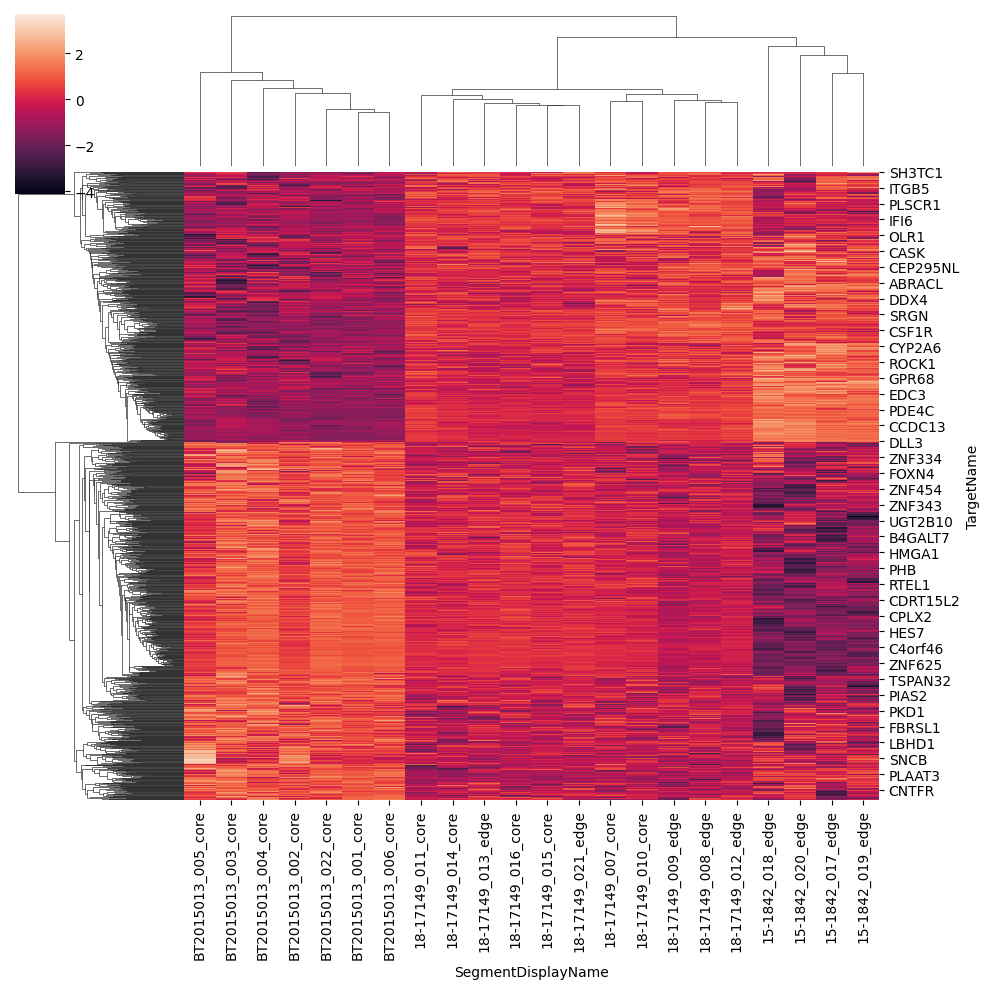

In [128]:
sns.clustermap(grapher, z_score=0)

In [129]:
#volcano
from sanbomics.plots import volcano

In [130]:
res
res['Symbol'] = res.index
res.reset_index(inplace=True, drop=True)

In [131]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
0,11.827130,0.077719,0.250621,0.310104,0.756482,0.894030,TLK1
1,13.825641,-0.853155,0.286397,-2.978922,0.002893,0.027592,APOL2
2,14.284347,0.036723,0.224444,0.163616,0.870033,0.945908,CIDEA
3,12.099556,0.041710,0.243928,0.170995,0.864228,0.943171,THOC1
4,10.249660,0.215652,0.280254,0.769488,0.441603,0.693734,VPS33B
...,...,...,...,...,...,...,...
8456,26.116471,-0.203976,0.251620,-0.810652,0.417566,0.673375,DYNC1LI2
8457,11.763186,0.572723,0.252375,2.269337,0.023248,0.118086,NADSYN1
8458,23.359060,0.148891,0.203969,0.729968,0.465410,0.713078,TPRA1
8459,10.212946,0.056895,0.305380,0.186308,0.852203,0.936915,TCF23


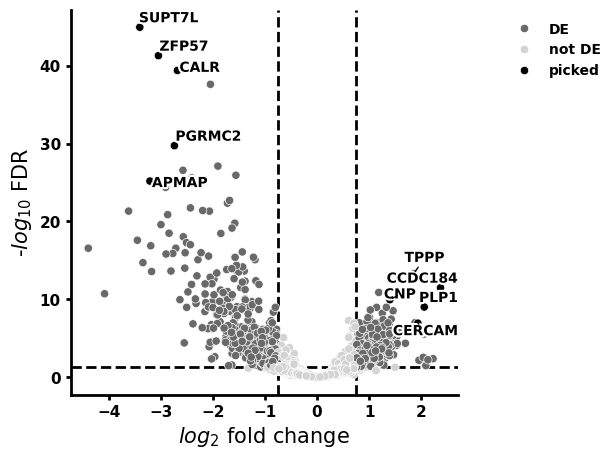

In [132]:
volcano(res, symbol='Symbol')

In [133]:
grapher.index

Index(['APOL2', 'BASP1', 'INTS1', 'PKD1', 'YAF2', 'BST2', 'DHRS1', 'OR6C74',
       'ZNF346', 'FERMT2',
       ...
       'DUOX1', 'RHOB', 'CLU', 'DKKL1', 'PLXNA2', 'TSPAN14', 'ISG15', 'OR10T2',
       'IL13', 'TAFA5'],
      dtype='object', name='TargetName', length=1466)

In [134]:
#GENE SET ENRICHMENT ANALYSIS
import gseapy
gene_set_names = gseapy.get_library_name(organism='Human')
print(gene_set_names)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency_CellLines_2023',

In [135]:
if 'Symbol' in res.columns:
    glist = res['Symbol'].str.strip().tolist()
else:
    glist = res.index.str.strip().tolist()

In [163]:
enr_res_bio = gseapy.enrichr(
    gene_list=glist,
    gene_sets='GO_Biological_Process_2025',
    organism='Human',
    outdir=None,
    cutoff=0.5
)

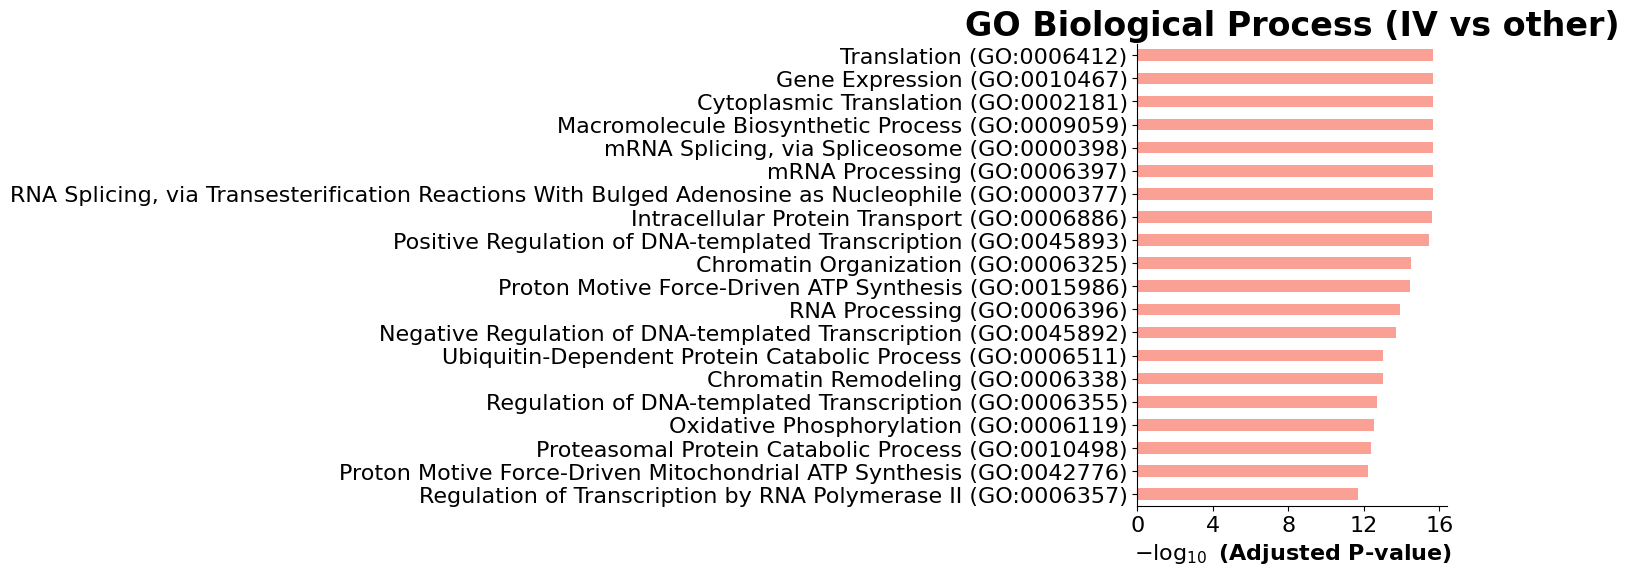

In [164]:
# Plot
gseapy.barplot(enr_res_bio.res2d, title='GO Biological Process (IV vs other)', top_term=20)
plt.tight_layout()
plt.show()

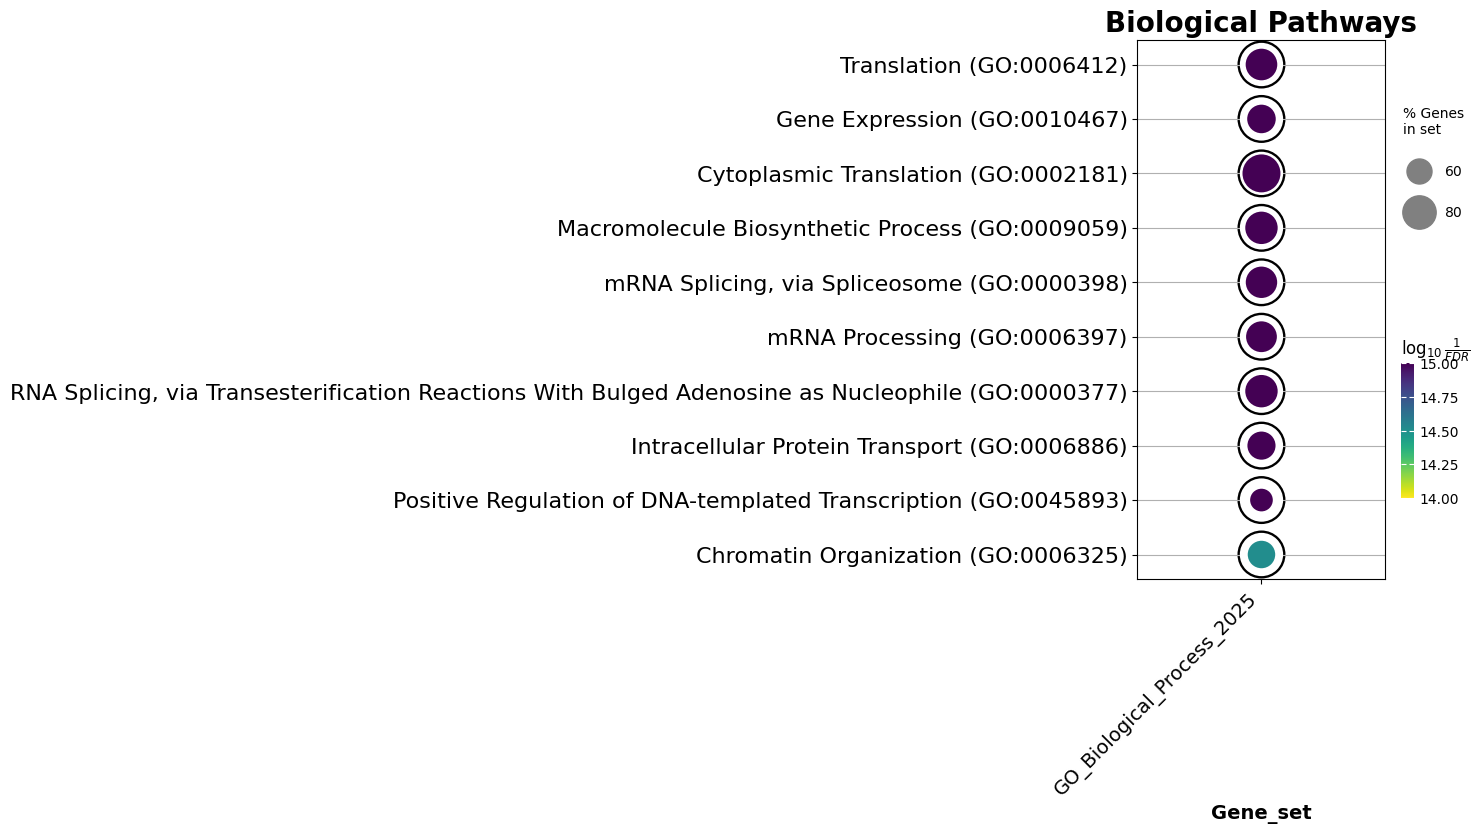

In [167]:
# categorical scatterplot
ax = dotplot(enr_res_bio.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=10,
              figsize=(4,7),
              title = "Biological Pathways",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [165]:
enr_res_bio = gseapy.enrichr(gene_list=glist, organism='Human', gene_sets='GO_Biological_Process_2025', cutoff = 0.5)
enr_res_bio.results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Translation (GO:0006412),176/232,1.514523e-25,5.013263e-22,0,0,4.355996,248.943121,RPL4;RPL5;RPL30;RPL32;RPL31;RPL34;RPL10L;RPL8;...
1,GO_Biological_Process_2025,Gene Expression (GO:0010467),261/381,1.902206e-25,5.013263e-22,0,0,3.028820,172.405327,RPL4;RPL5;ISCA1;RPL30;RPL32;RPL31;RPL34;EIF4A3...
2,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),92/101,5.267499e-25,9.254995e-22,0,0,14.083191,787.293614,EIF4A2;RPL4;EIF4A1;RPL5;RPL30;RPL32;RPL31;RPL3...
3,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),147/189,1.854908e-23,2.444305e-20,0,0,4.839969,253.331814,RPL4;RPL5;RPL30;RPL32;RPL31;RPL34;RPL10L;RPL10...
4,GO_Biological_Process_2025,"mRNA Splicing, via Spliceosome (GO:0000398)",159/211,1.114406e-22,1.174807e-19,0,0,4.230753,213.858432,EIF4A3;HNRNPU;HNRNPR;CASC3;CWC27;EFTUD2;PNN;SN...
5,GO_Biological_Process_2025,mRNA Processing (GO:0006397),167/226,3.536726e-22,3.107014e-19,0,0,3.917800,193.514547,TCERG1;RAMAC;EIF4A3;HNRNPU;HNRNPR;CASC3;CWC27;...
6,GO_Biological_Process_2025,"RNA Splicing, via Transesterification Reaction...",133/171,2.353388e-21,1.772101e-18,0,0,4.833513,229.584304,EIF4A3;HNRNPU;HNRNPR;CASC3;CWC27;EFTUD2;PNN;SN...
7,GO_Biological_Process_2025,Intracellular Protein Transport (GO:0006886),220/326,2.162278e-20,1.424671e-17,0,0,2.879368,130.379316,IPO13;VPS29;IPO11;PHB2;HERC2;CHORDC1;FAM53C;AK...
8,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,693/1274,2.026338e-19,1.186759e-16,0,0,1.682593,72.423677,SPI1;MAML2;MAML1;TRRAP;HNRNPU;GPATCH3;RBPJ;SOX...
9,GO_Biological_Process_2025,Chromatin Organization (GO:0006325),213/323,5.375492e-18,2.833422e-15,0,0,2.683160,106.694985,RB1;SMARCB1;EHMT1;HNRNPU;NUDT5;SOX2;TRIM28;MYC...


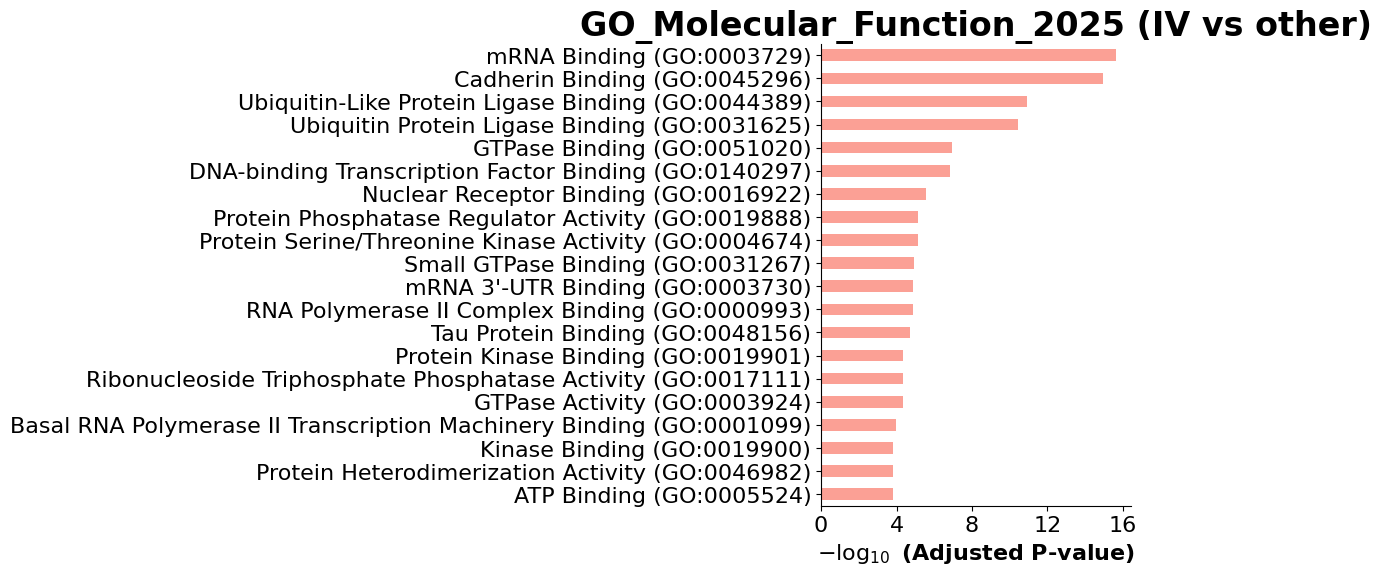

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Molecular_Function_2025,mRNA Binding (GO:0003729),219/310,2.744722e-24,3.134472e-21,0,0,3.342718,181.350346,EIF4A1;RPL5;EIF4A3;HNRNPU;HNRNPR;ADARB1;RPL7;T...
1,GO_Molecular_Function_2025,Cadherin Binding (GO:0045296),211/317,1.527281e-18,8.720774e-16,0,0,2.758563,113.164632,RPL34;ENO1;FNBP1L;RPL6;CRKL;GOLGA2;GOLGA3;PCMT...
2,GO_Molecular_Function_2025,Ubiquitin-Like Protein Ligase Binding (GO:0044...,183/284,3.294535e-14,1.254120e-11,0,0,2.503539,77.719684,RB1;RPL5;MPG;AUP1;CASC3;CLU;UBE2L3;LAPTM4B;HER...
3,GO_Molecular_Function_2025,Ubiquitin Protein Ligase Binding (GO:0031625),173/268,1.298106e-13,3.706091e-11,0,0,2.514494,74.611827,RB1;RPL5;MPG;AUP1;CASC3;CLU;UBE2L3;LAPTM4B;HER...
4,GO_Molecular_Function_2025,GTPase Binding (GO:0051020),141/225,5.080400e-10,1.160363e-07,0,0,2.311062,49.457792,USP6NL;CYFIP1;NCKAP1;RTKN;DENND5B;GCC2;CIB1;EN...
5,GO_Molecular_Function_2025,DNA-binding Transcription Factor Binding (GO:0...,176/294,7.980691e-10,1.518991e-07,0,0,2.056091,43.072687,RB1;TCERG1;CRTC2;SPI1;KDM1A;CRTC1;GTF2B;PRDM5;...
6,GO_Molecular_Function_2025,Nuclear Receptor Binding (GO:0016922),79/116,1.671043e-08,2.726187e-06,0,0,2.929888,52.466193,KDM5D;KDM1A;RNF14;GTF2B;TGFB1I1;JMJD1C;PARK7;P...
7,GO_Molecular_Function_2025,Protein Phosphatase Regulator Activity (GO:001...,55/75,4.826222e-08,6.889431e-06,0,0,3.768409,63.484950,ANKLE2;HSP90AB1;YWHAB;PPP2R2A;CABIN1;PPP1R9B;P...
8,GO_Molecular_Function_2025,Protein Serine/Threonine Kinase Activity (GO:0...,202/359,5.489718e-08,6.965843e-06,0,0,1.773139,29.642993,TRIO;TP53RK;ARAF;DCAF1;RPS6KA4;TBK1;AKT2;AKT3;...
9,GO_Molecular_Function_2025,Small GTPase Binding (GO:0031267),121/199,1.006303e-07,1.149198e-05,0,0,2.131804,34.347224,USP6NL;CYFIP1;NCKAP1;RTKN;DENND5B;GCC2;CIB1;RA...


In [168]:
enr_res_mf = gseapy.enrichr(
    gene_list=glist,
    gene_sets='GO_Molecular_Function_2025',
    organism='Human',
    outdir=None,
    cutoff=0.5
)

gseapy.barplot(enr_res_mf.res2d, title='GO_Molecular_Function_2025 (IV vs other)', top_term=20)
plt.tight_layout()
plt.show()

enr_res_mf = gseapy.enrichr(gene_list=glist, organism='Human', gene_sets='GO_Molecular_Function_2025', cutoff = 0.5)
enr_res_mf.results.head(10)

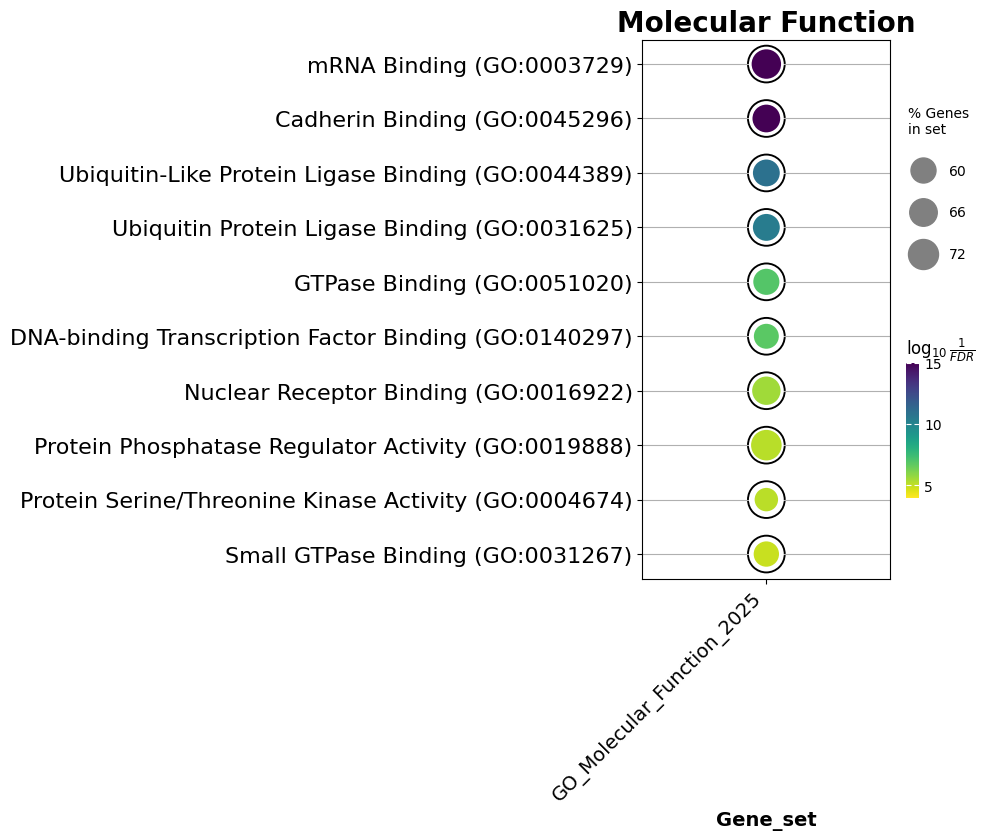

In [169]:
# categorical scatterplot
ax = dotplot(enr_res_mf.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=10,
              figsize=(4,7),
              title = "Molecular Function",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [170]:
enr_res_re = gseapy.enrichr(
    gene_list=glist,
    gene_sets='Reactome_Pathways_2024',  
    organism='Human',
    outdir=None,
    cutoff=0.5
)

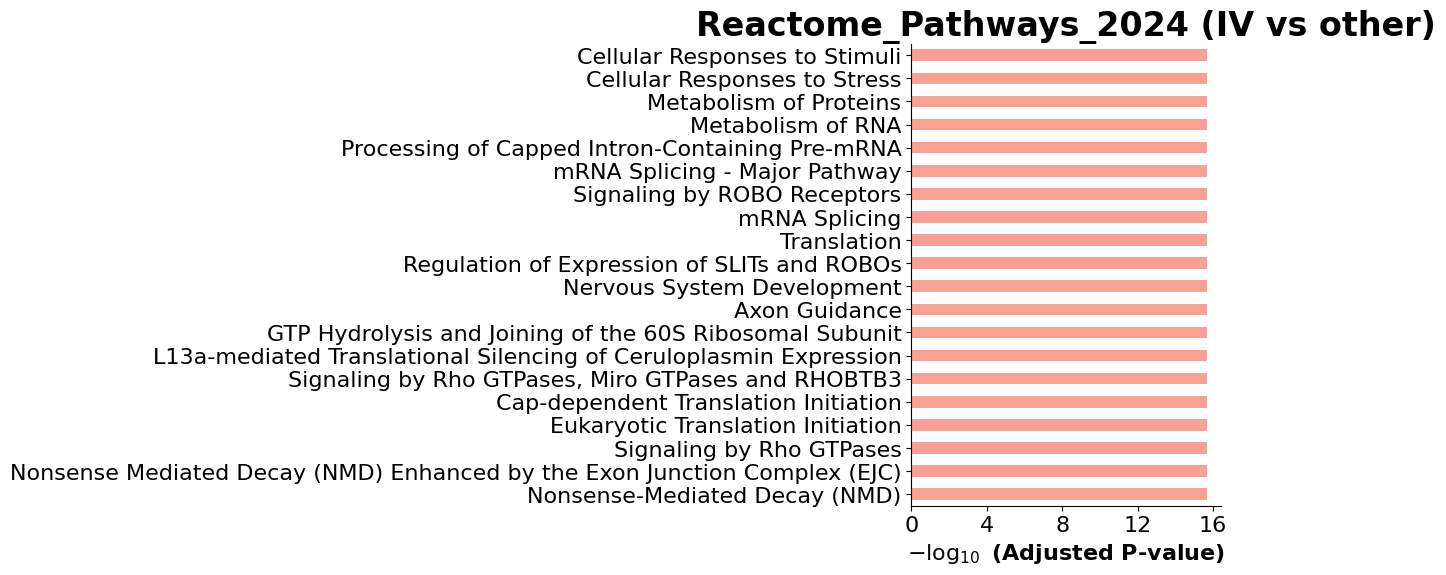

ConnectionError: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

In [ ]:
gseapy.barplot(enr_res_re.res2d, title='Reactome_Pathways_2024 (IV vs other)', top_term=20)
plt.tight_layout()
plt.show()

#enr_res_re = gseapy.enrichr(gene_list=glist, organism='Human', gene_sets='Reactome_Pathways_2024', cutoff = 0.01) #check if cutoff can be adjusted to 0.1 0r 0.9. also check if scale can be made loger
#enr_res_re.results.head(12)

(12.0, 20.0)

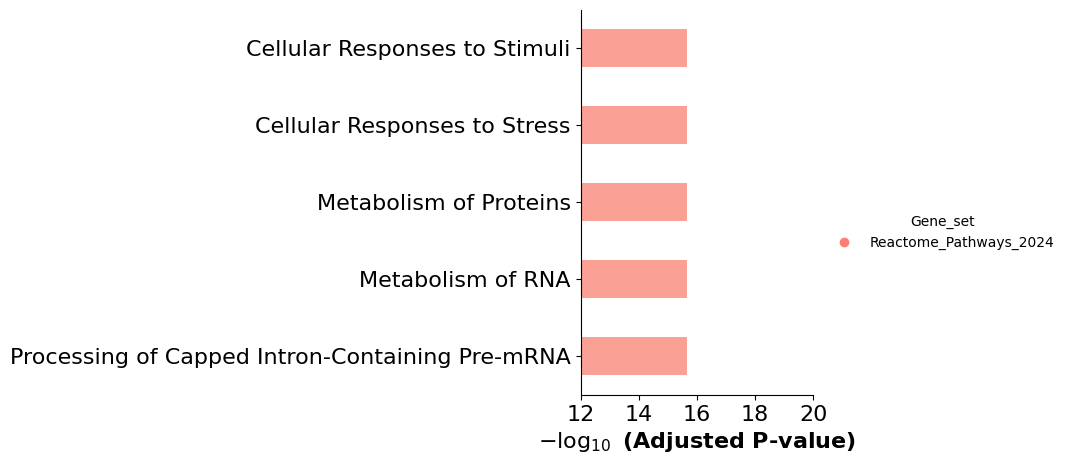

In [183]:
ax = barplot(enr_res_re.results,
              column="Adjusted P-value",
              group='Gene_set', # set group, so you could do a multi-sample/library comparsion
              size=10,
              top_term=5,
              figsize=(3,5),
              color = {'Reactome_2019_human': 'salmon'}
             )
ax.set_xlim(12, 20)  # x-axis limits
#ax.set_ylim(-0.5, 5.5)  # y-axis limits (useful for top_term bars)

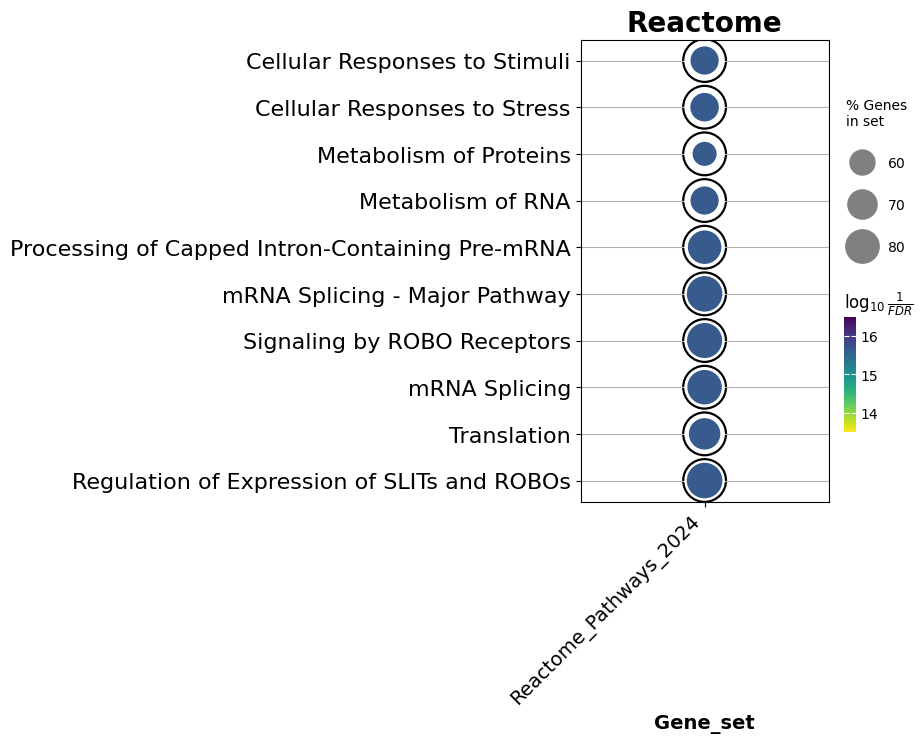

In [172]:
# categorical scatterplot
ax = dotplot(enr_res_re.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=10,
              figsize=(4,6),
              title = "Reactome",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

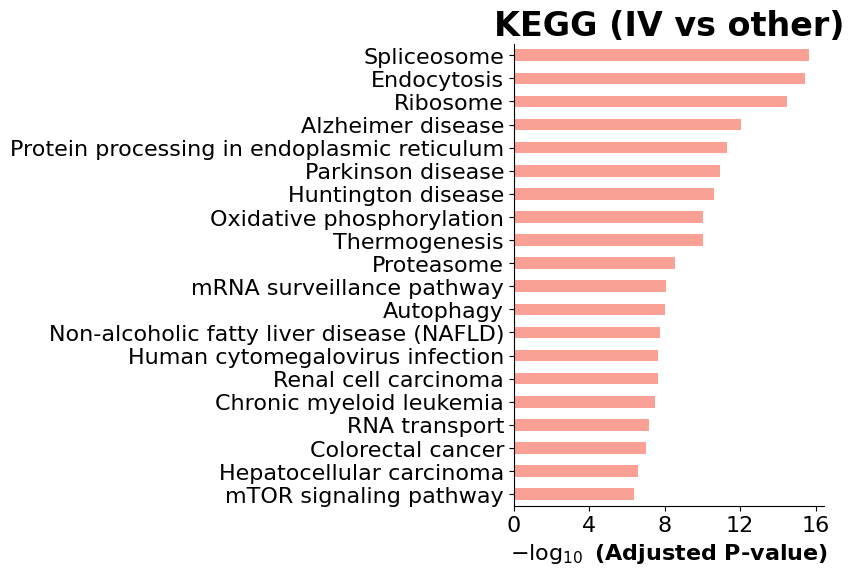

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2019_Human,Spliceosome,113/134,8.503814e-24,2.619175e-21,0,0,7.424270,394.388585,TCERG1;EIF4A3;HNRNPU;EFTUD2;SNRPD2;SNRPD1;MAGO...
1,KEGG_2019_Human,Endocytosis,171/244,1.080134e-18,1.663406e-16,0,0,3.239893,134.032578,WASHC4;VPS29;WASHC5;ZFYVE9;WIPF1;WIPF2;WIPF3;A...
2,KEGG_2019_Human,Ribosome,116/153,2.833260e-17,2.908814e-15,0,0,4.321189,164.648193,RPL4;RPL5;RPL30;RPL32;RPL31;RPL34;RPL10L;RPL8;...
3,KEGG_2019_Human,Alzheimer disease,122/171,1.170053e-14,9.009406e-13,0,0,3.430598,110.050636,APP;NDUFA13;NDUFA11;NDUFA12;NDUFA10;CALML3;CAL...
4,KEGG_2019_Human,Protein processing in endoplasmic reticulum,117/165,8.240177e-14,5.075949e-12,0,0,3.356821,101.131508,ERO1A;ERO1B;UBE2D4;UBE2D2;UBE2D3;UBE2D1;CAPN2;...
5,KEGG_2019_Human,Parkinson disease,103/142,2.416585e-13,1.240514e-11,0,0,3.633859,105.568154,NDUFA13;NDUFA11;NDUFA12;NDUFA10;UBE2L6;PARK7;C...
6,KEGG_2019_Human,Huntington disease,131/193,5.358223e-13,2.357618e-11,0,0,2.911139,82.254164,NDUFA13;NDUFA11;NDUFA12;NDUFA10;COX6A1;COX6A2;...
7,KEGG_2019_Human,Oxidative phosphorylation,96/133,2.527331e-12,9.311765e-11,0,0,3.567606,95.268850,NDUFA13;COX7B;NDUFA11;NDUFA12;COX4I1;NDUFA10;T...
8,KEGG_2019_Human,Thermogenesis,150/231,2.720970e-12,9.311765e-11,0,0,2.553064,67.988189,ATF2;NDUFA13;SMARCB1;NDUFA11;KDM1A;NDUFA12;NDU...
9,KEGG_2019_Human,Proteasome,40/45,9.308902e-11,2.867142e-09,0,0,10.957368,253.087434,PSMD12;PSMD11;PSMD14;POMP;PSMA7;PSMB10;PSMD8;P...


In [173]:
enr_res_kegg = gseapy.enrichr(
    gene_list=glist,
    gene_sets='KEGG_2019_Human',  
    organism='Human',
    outdir=None,
    cutoff=0.5
)
gseapy.barplot(enr_res_kegg.res2d, title='KEGG (IV vs other)', top_term=20)
plt.tight_layout()
plt.show()

enr_res_kegg = gseapy.enrichr(gene_list=glist, organism='Human', gene_sets='KEGG_2019_Human', cutoff = 0.5)
enr_res_kegg.results.head(10)

In [144]:
from gseapy import barplot, dotplot

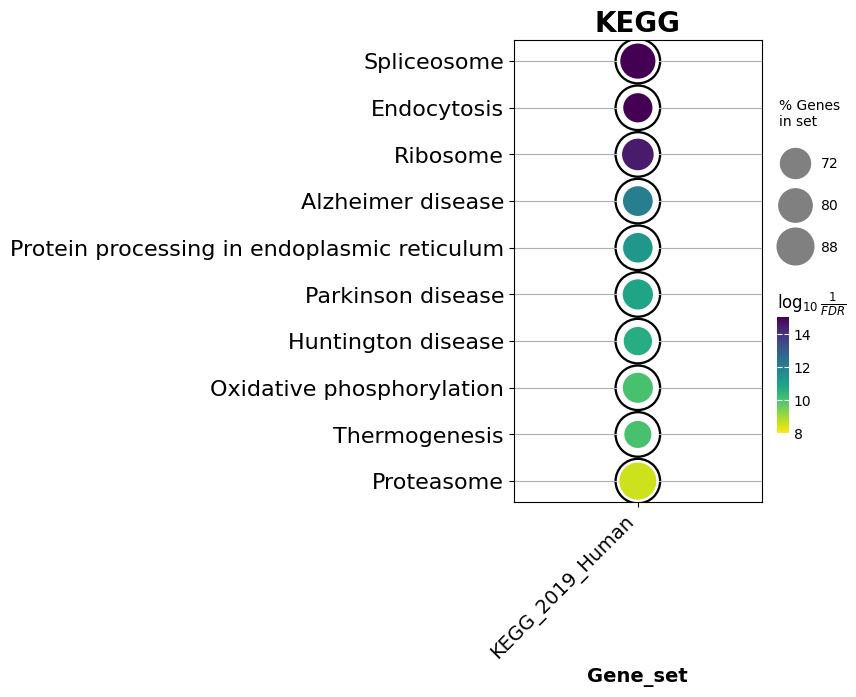

In [174]:
# categorical scatterplot
ax = dotplot(enr_res_kegg.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=10,
              figsize=(4,6),
              title = "KEGG",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )